In [2]:
# import libararies
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report


In [8]:
 

df = pd.read_csv("ecommerce_customers_unit1.csv")
df.head()


,customer_id,age,gender,country,signup_date,last_purchase_date,num_orders,total_spent,avg_order_value,recency_days,is_premium_member,device_type,preferred_category,churned
0,10001,56.0,Male,India,2022-01-27,2024-04-27,10,13273.25,1327.32,522,0,NaN,Home,0
1,10002,69.0,Other,UK,2025-01-12,2025-08-01,10,NaN,308.90,61,0,Mobile,Grocery,0
2,10003,46.0,Female,USA,2021-04-25,2021-06-01,5,3411.83,682.37,1583,0,NaN,NaN,0
3,10004,32.0,Male,India,2021-02-23,2023-09-22,5,4502.00,900.40,740,0,NaN,NaN,0
4,10005,60.0,Female,India,2021-06-07,2021-12-11,7,3842.10,548.87,1390,0,Tablet,Books,0


In [10]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         605 non-null    int64  
 1   age                 577 non-null    float64
 2   gender              571 non-null    object 
 3   country             573 non-null    object 
 4   signup_date         605 non-null    object 
 5   last_purchase_date  605 non-null    object 
 6   num_orders          605 non-null    int64  
 7   total_spent         571 non-null    float64
 8   avg_order_value     605 non-null    float64
 9   recency_days        605 non-null    int64  
 10  is_premium_member   605 non-null    int64  
 11  device_type         575 non-null    object 
 12  preferred_category  583 non-null    object 
 13  churned             605 non-null    int64  
dtypes: float64(3), int64(5), object(6)
memory usage: 66.3+ KB
None
        customer_id         age  ...  is_pr

In [11]:
df.isnull().sum()

customer_id            0
age                   28
gender                34
country               32
signup_date            0
last_purchase_date     0
num_orders             0
total_spent           34
avg_order_value        0
recency_days           0
is_premium_member      0
device_type           30
preferred_category    22
churned                0
dtype: int64

In [14]:
# preprocessing data
# fill null value of age column by mean
df['age'] = df['age'].fillna(df['age'].mean())


In [17]:
df.isnull().sum()
df['total_spent'] = df['total_spent'].fillna(df['total_spent'].mean())

In [19]:
df.isnull().sum()

customer_id            0
age                    0
gender                34
country               32
signup_date            0
last_purchase_date     0
num_orders             0
total_spent            0
avg_order_value        0
recency_days           0
is_premium_member      0
device_type           30
preferred_category    22
churned                0
dtype: int64

In [22]:
# handle missing categorical values
# df['gender'].mode()[0]
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])


In [ ]:
df['country'] = df['country'].fillna('Unknown')



In [24]:
df['preferred_category'] = df['preferred_category'].fillna('Unknown')

In [25]:
df['device_type'] = df['device_type'].fillna('Unknown')


In [26]:
df.isnull().sum()

customer_id           0
age                   0
gender                0
country               0
signup_date           0
last_purchase_date    0
num_orders            0
total_spent           0
avg_order_value       0
recency_days          0
is_premium_member     0
device_type           0
preferred_category    0
churned               0
dtype: int64

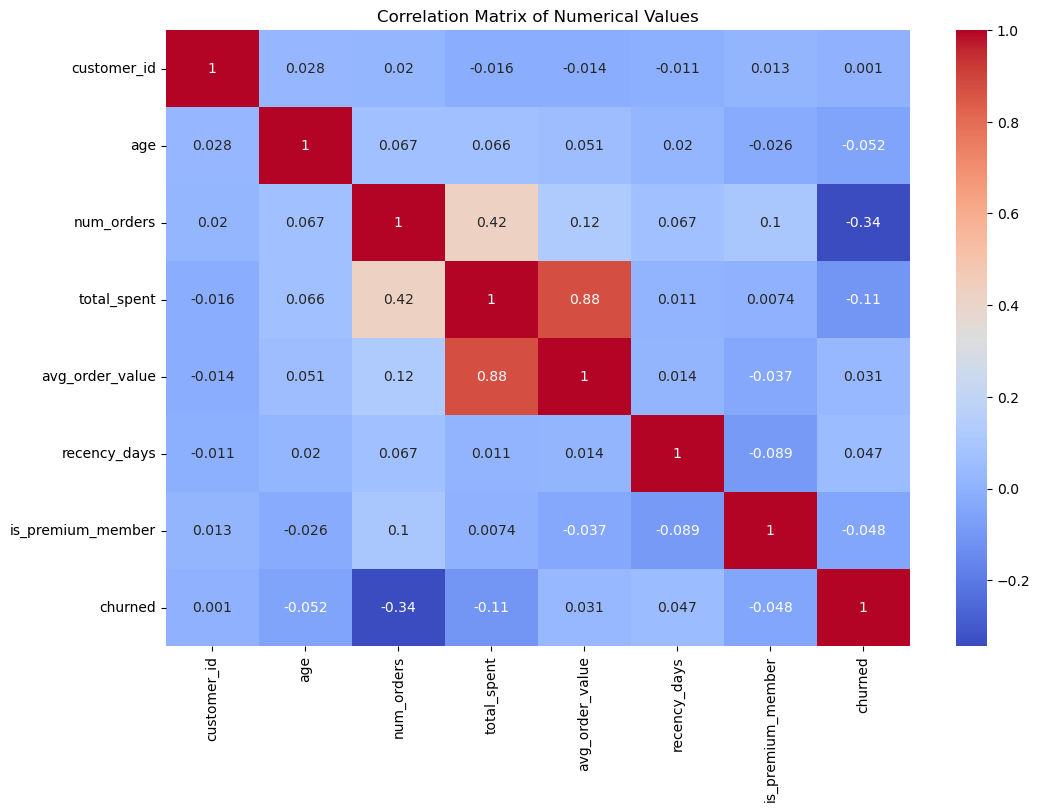

In [27]:
# Numeric correlation
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Numerical Values")
plt.show()

In [28]:
df.head()

,customer_id,age,gender,country,signup_date,last_purchase_date,num_orders,total_spent,avg_order_value,recency_days,is_premium_member,device_type,preferred_category,churned
0,10001,56.0,Male,India,2022-01-27,2024-04-27,10,13273.250000,1327.32,522,0,Unknown,Home,0
1,10002,69.0,Other,UK,2025-01-12,2025-08-01,10,8059.212137,308.90,61,0,Mobile,Grocery,0
2,10003,46.0,Female,USA,2021-04-25,2021-06-01,5,3411.830000,682.37,1583,0,Unknown,Unknown,0
3,10004,32.0,Male,India,2021-02-23,2023-09-22,5,4502.000000,900.40,740,0,Unknown,Unknown,0
4,10005,60.0,Female,India,2021-06-07,2021-12-11,7,3842.100000,548.87,1390,0,Tablet,Books,0


In [33]:
# feature selection
num_cols = df.select_dtypes(include=[np.number]).columns.drop("avg_order_value")
X = df[num_cols]
Y = df["avg_order_value"]

# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=123)

X_train.shape, X_test.shape

((484, 7), (121, 7))

MAE=370.48, MSE=345490.25, RMSE=587.78, R²=0.74


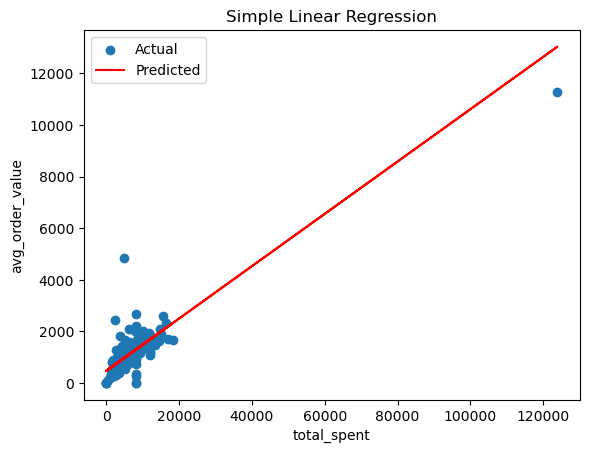

In [37]:
model = LinearRegression()
X_train_model = X_train[['total_spent']]   # ✅ a real feature
X_test_model = X_test[['total_spent']]

model.fit(X_train_model, y_train)
y_pred_model = model.predict(X_test_model)

mae = mean_absolute_error(y_test, y_pred_model)
mse = mean_squared_error(y_test, y_pred_model)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred_model)

print(f"MAE={mae:.2f}, MSE={mse:.2f}, RMSE={rmse:.2f}, R²={r2:.2f}")

plt.scatter(X_test_model, y_test, label="Actual")
plt.plot(X_test_model, y_pred_model, color='red', label="Predicted")
plt.xlabel("total_spent")
plt.ylabel("avg_order_value")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()
